# Synthetic demand from any distribution

`DemandGenerator` ships with normal, seasonal, and trend demand. When you need
something else (Poisson counts, intermittent sales, a resampled history) you
write a **sampler**: a small function that draws demand, which the generator
turns into a complete, seeded, validated demand table.

This notebook builds a three-product panel two ways, one sampler for all
products and one sampler per product, then runs it through the engine.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stockcast.core import InventoryStateDataFrame, SimulationEngine
from stockcast.policies import OrderUpToPolicy
from stockcast.utils import DemandGenerator

## 1. The generator owns the calendar and the seed

The generator is declared once: which SKUs, the date of period 0, the period
length, and the seed. Every table it produces uses that calendar and draws from
that one seeded random stream.

In [2]:
skus = ["tea_250g", "coffee_1kg", "honey_jar"]
opening_date = pd.Timestamp("2026-01-05")   # the day we count the shelf

generator = DemandGenerator(
    skus,
    start_date=opening_date + pd.Timedelta(days=1),   # date of period 0
    period_frequency="D",
    random_seed=9,
)

## 2. One sampler for the whole panel

A sampler has the signature `sampler(rng, periods)` and returns one value per
period. `rng` is the generator's seeded stream; `periods` holds the period
indices. Passed on its own, one sampler generates every SKU, each with its own
independent draws.

In [3]:
def poisson(rng, periods):
    return rng.poisson(6.0, periods.size)

panel = generator.sample(n_periods=28, sampler=poisson)
print(panel.head(6))

    unique_id    y  period       date
0    tea_250g  8.0       0 2026-01-06
1  coffee_1kg  3.0       0 2026-01-06
2   honey_jar  4.0       0 2026-01-06
3    tea_250g  3.0       1 2026-01-07
4  coffee_1kg  6.0       1 2026-01-07
5   honey_jar  9.0       1 2026-01-07


The result is the standard demand table: one row per SKU and period, with
`unique_id`, `y`, `period`, and `date`. All three products follow the same
Poisson(6) distribution but get different paths.

In [4]:
print(panel.pivot(index="date", columns="unique_id", values="y").head(4))

unique_id   coffee_1kg  honey_jar  tea_250g
date                                       
2026-01-06         3.0        4.0       8.0
2026-01-07         6.0        9.0       3.0
2026-01-08        12.0        3.0      14.0
2026-01-09         4.0        6.0       6.0


## 3. One sampler per SKU

Real products rarely share one demand model. A dict assigns a sampler to each
SKU, exactly like a dict of parameters:

- **tea** sells more on weekends: its Poisson rate depends on the period;
- **coffee** resamples its own sales history;
- **honey** is intermittent: it sells on about 30% of days, a few jars at a time.

In [5]:
def busy_weekends(rng, periods):
    weekday = (opening_date + pd.to_timedelta(periods + 1, unit="D")).dayofweek
    rate = np.where(weekday >= 5, 9.0, 6.0)          # Saturday and Sunday
    return rng.poisson(rate)

coffee_history = np.array([2, 3, 1, 4, 2, 0, 3, 5, 2, 1, 3, 2, 4, 1])

def resample_history(rng, periods):
    return rng.choice(coffee_history, periods.size)

def intermittent(rng, periods):
    sells = rng.binomial(1, 0.3, periods.size)
    return sells * rng.poisson(3.0, periods.size)

samplers = {
    "tea_250g": busy_weekends,
    "coffee_1kg": resample_history,
    "honey_jar": intermittent,
}
demand = generator.sample(n_periods=28, sampler=samplers)

summary = demand.groupby("unique_id")["y"].agg(
    mean="mean", zero_days=lambda y: int((y == 0).sum()), max="max",
)
print(summary.loc[skus])

                mean  zero_days   max
unique_id                            
tea_250g    7.000000          0  15.0
coffee_1kg  2.000000          4   4.0
honey_jar   1.285714         19   6.0


Tea averages about seven a day with weekend peaks, coffee stays within its
historical range, and honey has many zero days. The figure shows the three
shapes on one shared scale.

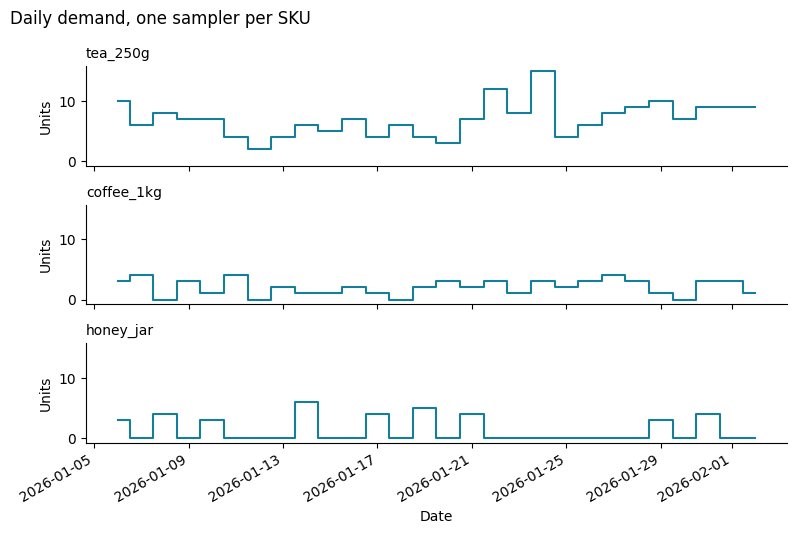

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(8, 5.4), sharex=True, sharey=True)
for ax, sku in zip(axes, skus):
    series = demand[demand["unique_id"] == sku]
    ax.step(series["date"], series["y"], where="mid", color="#167d9a")
    ax.set_title(sku, loc="left", fontsize=10)
    ax.set_ylabel("Units")
    ax.spines[["top", "right"]].set_visible(False)
axes[-1].set_xlabel("Date")
fig.suptitle("Daily demand, one sampler per SKU", x=0.01, ha="left")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 4. Same seed, same panel

Because every sampler draws from the generator's `rng`, a new generator with the
same seed reproduces the table exactly. That is what makes a synthetic
experiment repeatable.

In [7]:
again = DemandGenerator(
    skus,
    start_date=opening_date + pd.Timedelta(days=1),
    period_frequency="D",
    random_seed=9,
)
pd.testing.assert_frame_equal(panel, again.sample(n_periods=28, sampler=poisson))
print("identical demand tables")

identical demand tables


The generator also checks what a sampler returns. A sampler that returns the
wrong number of values, non-numeric values, or `NaN` stops with a message
naming the SKU:

In [8]:
def one_value_only(rng, periods):
    return [5.0]

try:
    generator.sample(n_periods=28, sampler=one_value_only)
except ValueError as error:
    print(error)

sampler for SKU 'tea_250g' returned shape (1,); expected (28,), one value per period


Negative draws follow `negative_demand_handling`, just as they do for the
built-in methods: the default raises, `"clip_zero"` clips and warns.

## 5. Into the engine

Every generator method has an `_fn` twin. `sample_fn(samplers)` returns a
function `period -> DataFrame`, which the engine accepts as `demand_source`.
The engine calls it once per period before the run, validates the complete
table, and then simulates. We give it a fresh generator with the same seed, so
the run is reproducible. The period-by-period twin draws in a different order
than `sample`, so its path is a new draw from the same three models.

The policy is an order-up-to rule with lead time 2 and a review every 4 days.
Its targets come from the same samplers: 10,000 planning paths over the 6-day
protection window from a separate planning stream. Each path is summed first,
then the 95% quantile of the totals is taken.

In [9]:
lead_time, review_period = 2, 4
horizon = lead_time + review_period

planning_rng = np.random.default_rng(42)            # separate from the demand seed
grid = np.tile(np.arange(horizon), 10_000)          # 10,000 paths of 6 days
target = pd.DataFrame({
    "unique_id": skus,
    "target": [
        np.quantile(samplers[sku](planning_rng, grid).reshape(10_000, horizon).sum(axis=1), 0.95)
        for sku in skus
    ],
    "target_end_date": opening_date + pd.Timedelta(days=horizon),
})
print(target)

    unique_id  target target_end_date
0    tea_250g    53.0      2026-01-11
1  coffee_1kg    20.0      2026-01-11
2   honey_jar    13.0      2026-01-11


In [10]:
inventory = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    pd.DataFrame({"unique_id": skus, "on_hand": [30.0, 10.0, 5.0]}),
    on_hand_column="on_hand",
    start_date=opening_date,
)

policy = OrderUpToPolicy(
    lead_time=lead_time,
    review_period=review_period,
    service_level=0.95,
    allow_backorders=False,
).fit(
    target,
    target_column="target",
    target_probability=0.95,
    protection_horizon=horizon,
    target_source="external_direct",
    forecast_origin=opening_date,
    forecast_frequency="D",
    target_end_date_column="target_end_date",
)

engine_generator = DemandGenerator(
    skus,
    start_date=opening_date + pd.Timedelta(days=1),
    period_frequency="D",
    random_seed=9,
)
result = SimulationEngine().run(
    policy=policy,
    demand_source=engine_generator.sample_fn(samplers),   # period -> DataFrame
    inventory=inventory,
    n_periods=28,
    period_frequency="D",
    warmup_periods=0,
    scoring_periods=28,
    settlement_periods=0,
    order_during_settlement=False,
    demand_source_name="three_samplers",
    random_seed=9,
)

The event ledger shows how each product fared over the four weeks:

In [11]:
events = result.to_event_frame()
totals = events.groupby("unique_id")[
    ["demand", "fulfilled_units", "lost_sales_units"]
].sum()
totals["fill_rate"] = (totals["fulfilled_units"] / totals["demand"]).round(3)
print(totals.loc[skus])

            demand  fulfilled_units  lost_sales_units  fill_rate
unique_id                                                       
tea_250g     203.0            203.0               0.0       1.00
coffee_1kg    61.0             61.0               0.0       1.00
honey_jar     33.0             32.0               1.0       0.97


Tea and coffee are fully served. Honey, the intermittent product, loses one
jar: its sales arrive in lumps, so a single six-day window can exceed even a 95%
target. Swapping a sampler is all it takes to stress a policy on a different
demand shape.

The run manifest records where the demand came from: the source name, the
seed, a fingerprint of the table, and the generator's negative-draw handling.

In [12]:
source = result.run_manifest["demand_source"]
print({key: source[key] for key in ["name", "type", "rows", "random_seed"]})
print(source["generation_provenance"])

{'name': 'three_samplers', 'type': 'callable', 'rows': 84, 'random_seed': 9}
{'negative_demand_handling': 'raise', 'clipped_negative_count': 0, 'minimum_clipped_value': None}


## Where to go next

- [Demand and calendars](https://filtheo.github.io/stockcast/user-guide/demand/)
  covers the demand table, every generator method, and more sampler recipes.
- Notebook 04c turns forecast sample paths into protection targets in detail.